# High level map segmentation
The goal is to convert the pathfinding algorithm into a two level search through new map representations.

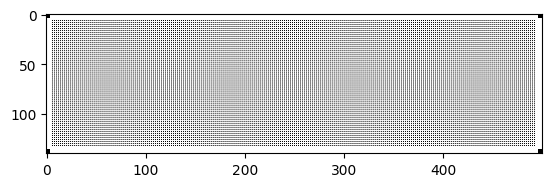

In [30]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

DOMAIN = 'warehouse'
MAP = 'sortation_large.map'
WALLS = ['T', '@']
maps_path = Path(f'../example_problems/{DOMAIN}.domain/maps/')
map_path = maps_path / MAP
with map_path.open() as f:
    lines = f.readlines()
lines = [line.strip() for line in lines if line.strip()]
lines = lines[4:] # ignore headers

map_ = np.array([list(line) for line in lines])
map_ = np.where(np.isin(map_, WALLS), 1, 0).astype(np.bool)
h, w = map_.shape

plt.imshow(1 - map_, cmap='gray')

In [31]:
from py_floor_plan_segmenter.modules import do_segment
import yaml
with open('py_floor_plan_segmenter/default.yml', 'r') as f:
    config = yaml.safe_load(f)

# Remap bool for compatibility
np.bool = np.bool_
np.bool8 = np.bool_

In [32]:
from skimage import color

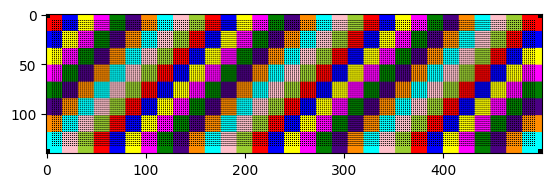

In [35]:
import numpy as np
from skimage.morphology import remove_small_objects

def segment_map_into_grid(map_, n_clusters_x=5, n_clusters_y=5):
    """
    Segment map's interior space into a grid.
    
    Parameters:
    - map_: Binary 2D numpy array
    - n_clusters_x: Number of horizontal grid segments
    - n_clusters_y: Number of vertical grid segments
    
    Returns:
    - Labeled interior segmentation map
    """
    # Invert map to get interior space
    interior = 1 - map_
    
    # Remove small noise objects
    interior = remove_small_objects(interior.astype(bool), min_size=10)
    
    # Get map dimensions
    height, width = interior.shape
    
    # Create segmentation
    segmentation = np.zeros_like(interior, dtype=np.uint)
    
    # Compute grid cell sizes
    x_step = width // n_clusters_x
    y_step = height // n_clusters_y
    
    # Assign labels based on grid
    for y in range(n_clusters_y):
        for x in range(n_clusters_x):
            # Compute grid region
            x_start = x * x_step
            x_end = (x + 1) * x_step if x < n_clusters_x - 1 else width
            y_start = y * y_step
            y_end = (y + 1) * y_step if y < n_clusters_y - 1 else height
            
            # Create grid-based label
            label = y * n_clusters_x + x + 1
            
            # Mask grid region
            grid_region = interior[y_start:y_end, x_start:x_end]
            
            # Only assign label to interior regions
            if np.any(grid_region):
                segmentation[y_start:y_end, x_start:x_end][grid_region] = label
    
    return segmentation

clusters_x = map_.shape[1] // 2**4
clusters_y = map_.shape[0] // 2**4
segmentation = segment_map_into_grid(map_, n_clusters_x=clusters_x, n_clusters_y=clusters_y)
plt.imshow(color.label2rgb(segmentation))

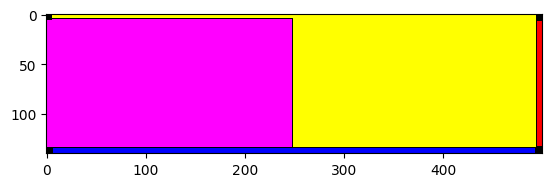

In [34]:
# Generate an initial segmentation, based on py_floor_plan_segmenter
# but without preprocessing (not needed) and merging (not desired)
segmentation = do_segment(map_.astype(np.float32), **config)
# Remove border label
segmentation[segmentation == 255] = 0
plt.imshow(color.label2rgb(segmentation))

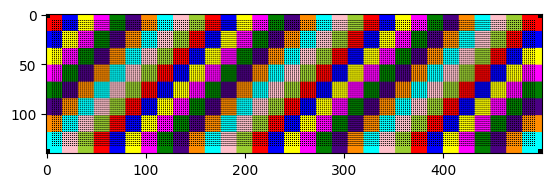

In [36]:
# Identify labels that are not useful and remove them
segmentation *= (map_ == 0)
labels, counts = np.unique(segmentation, return_counts=True)
labels = labels[1:] # ignore 0
counts = counts[1:] # ignore 0
valid_counts = (counts / counts.sum()) >= 0.0001
valid_labels = labels[valid_counts]
valid_labels
segmentation[~np.isin(segmentation, valid_labels)] = 0
plt.imshow(color.label2rgb(segmentation))


## Fixing the segmentation
Segmentations generated using this method usually eliminate some pixels which we need for our task. We can recover those pixels through a voting system, such that unlabeled pixels are assigned the label that is most representative of its surroundings

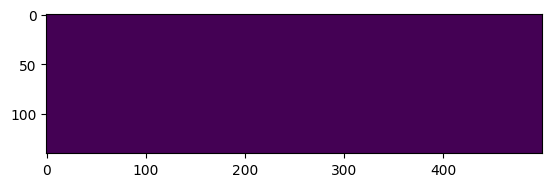

In [37]:
missed_pixels = ((segmentation == 0) + (segmentation == 255)) * (map_ == 0)
plt.imshow(missed_pixels)

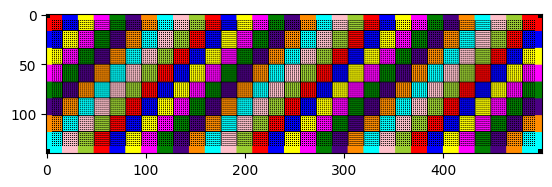

In [38]:
import numpy as np
from scipy.signal import convolve2d
from scipy.ndimage import label

def clean_disjoint_labels(segmentation):
    """
    Clean segmentation map by removing pixels that don't have neighbors
    of the same label in all cardinal directions, then relabel connected
    components with unique labels.
    
    Parameters:
    - segmentation: 2D numpy array of labeled segments
    
    Returns:
    - Cleaned and relabeled segmentation map where each connected
      component has a unique label
    """
    # Define cross kernel without center
    kernel = np.array([
        [0, 1, 0],
        [1, 0, 1],
        [0, 1, 0]
    ])
    
    # Get unique labels (excluding background/border)
    unique_labels = np.unique(segmentation)
    unique_labels = unique_labels[(unique_labels != 0) & (unique_labels != 255)]
    
    # Initialize mask for all valid pixels
    valid_pixels = np.zeros_like(segmentation, dtype=bool)
    
    for label_value in unique_labels:
        # Create binary mask for current label
        mask = (segmentation == label_value)
        
        # Convolve with cross kernel
        neighbor_count = convolve2d(mask.astype(int), kernel, mode='same')
        
        # Add pixels with all 4 cardinal neighbors to valid pixels mask
        valid_pixels |= (neighbor_count > 1) & mask
    
    # Create initial cleaned map
    cleaned = np.zeros_like(segmentation)
    cleaned[valid_pixels] = segmentation[valid_pixels]
    
    return cleaned

corrected_segmentation = clean_disjoint_labels(segmentation)
plt.imshow(color.label2rgb(corrected_segmentation))

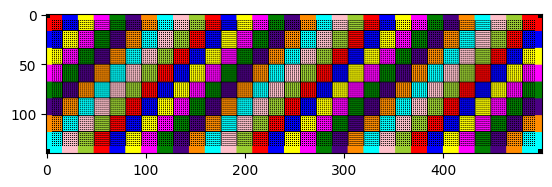

In [39]:
import numpy as np
from scipy.ndimage import label as scipy_label

def detect_disjoint_label_sections(segmentation):
    """
    Identify and correct labels that appear in disjoint sections.
    
    Parameters:
    - segmentation: 2D numpy array of labeled segments
    
    Returns:
    - Corrected segmentation
    - Dictionary of disjoint label sections
    """
    # Remove background labels
    valid_labels = np.unique(segmentation)
    valid_labels = valid_labels[(valid_labels != 0) & (valid_labels != 255)]
    
    disjoint_sections = {}
    corrected_segmentation = segmentation.copy()
    
    for label in valid_labels:
        # Create binary mask for current label
        label_mask = (segmentation == label)
        
        # Find connected components
        labeled_components, num_components = scipy_label(label_mask)
        
        if num_components > 1:
            # Track disjoint sections
            disjoint_sections[label] = num_components
            
            # Keep only the largest component
            largest_component_label = np.argmax(
                [np.sum(labeled_components == i) for i in range(1, num_components + 1)]
            ) + 1
            
            # Correct segmentation to keep only largest component
            corrected_mask = (labeled_components == largest_component_label)
            corrected_segmentation[label_mask] = 0
            corrected_segmentation[corrected_mask] = label
    
    return corrected_segmentation, disjoint_sections

corrected_segmentation, disjoint_sections = detect_disjoint_label_sections(corrected_segmentation)
plt.imshow(color.label2rgb(corrected_segmentation))

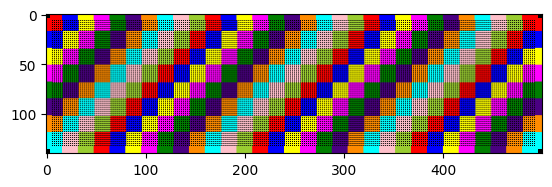

In [40]:
import numpy as np

def label_missed_pixels(map_, segmentation, max_iters=100000):
    """
    Label missed pixels using only cardinal direction neighbors (up, down, left, right).
    
    Parameters:
    - map_: Original binary map
    - segmentation: Segmentation map to be filled
    - max_iters: Maximum number of iterations to prevent infinite loops
    
    Returns:
    - Fully labeled segmentation map
    """
    # Pad maps to handle edge cases
    seg_padded = np.pad(segmentation, 1, mode='constant', constant_values=-1)
    map_padded = np.pad(map_, 1, mode='constant', constant_values=-1)
    
    # Find missed pixels
    missed_pixels = ((seg_padded == 0) + (seg_padded == 255)) * (map_padded == 0)
    
    # Cardinal direction offsets (up, down, left, right)
    cardinal_offsets = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    
    # Continue until no missed pixels remain
    iters = 0
    while np.any(missed_pixels) and iters < max_iters:
        # Create a working copy of the segmentation
        new_seg = seg_padded.copy()
        
        # Find coordinates of missed pixels
        missed_coords = np.argwhere(missed_pixels)
        
        for y, x in missed_coords:
            # Collect valid labels from cardinal neighbors
            neighbor_labels = []
            
            for dy, dx in cardinal_offsets:
                neighbor_label = seg_padded[y + dy, x + dx]
                if neighbor_label not in [-1, 0, 255]:
                    neighbor_labels.append(neighbor_label)
            
            # If valid labels exist, use mode (most frequent)
            if neighbor_labels:
                unique_labels, counts = np.unique(neighbor_labels, return_counts=True)
                new_label = unique_labels[np.argmax(counts)]
                new_seg[y, x] = new_label
        
        # Update segmentation and missed pixels
        seg_padded = new_seg
        missed_pixels = ((seg_padded == 0) + (seg_padded == 255)) * (map_padded == 0)
        iters += 1
    
    # Remove padding and return
    return seg_padded[1:-1, 1:-1]

# Example usage:
labeled_segmentation = label_missed_pixels(map_, corrected_segmentation, max_iters=500)
plt.imshow(color.label2rgb(labeled_segmentation))

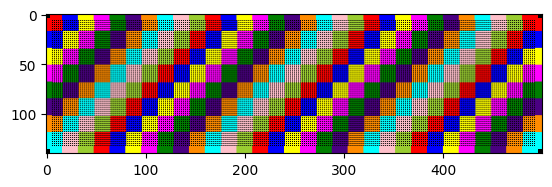

In [41]:
import numpy as np

def label_missed_pixels(map_, segmentation, max_iters=100000):
    """
    Label missed pixels using only cardinal direction neighbors (up, down, left, right).
    
    Parameters:
    - map_: Original binary map
    - segmentation: Segmentation map to be filled
    - max_iters: Maximum number of iterations to prevent infinite loops
    
    Returns:
    - Fully labeled segmentation map
    """
    # Pad maps to handle edge cases
    seg_padded = np.pad(segmentation, 1, mode='constant', constant_values=-1)
    map_padded = np.pad(map_, 1, mode='constant', constant_values=-1)
    
    # Find missed pixels
    missed_pixels = ((seg_padded == 0) + (seg_padded == 255)) * (map_padded == 0)
    
    # Cardinal direction offsets (up, down, left, right)
    cardinal_offsets = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    
    # Continue until no missed pixels remain
    iters = 0
    while np.any(missed_pixels) and iters < max_iters:
        # Create a working copy of the segmentation
        new_seg = seg_padded.copy()
        
        # Find coordinates of missed pixels
        missed_coords = np.argwhere(missed_pixels)
        
        for y, x in missed_coords:
            # Collect valid labels from cardinal neighbors
            neighbor_labels = []
            
            for dy, dx in cardinal_offsets:
                neighbor_label = seg_padded[y + dy, x + dx]
                if neighbor_label not in [-1, 0, 255]:
                    neighbor_labels.append(neighbor_label)
            
            # If valid labels exist, use mode (most frequent)
            if neighbor_labels:
                unique_labels, counts = np.unique(neighbor_labels, return_counts=True)
                new_label = unique_labels[np.argmax(counts)]
                new_seg[y, x] = new_label
        
        # Update segmentation and missed pixels
        seg_padded = new_seg
        missed_pixels = ((seg_padded == 0) + (seg_padded == 255)) * (map_padded == 0)
        iters += 1
    
    # Remove padding and return
    return seg_padded[1:-1, 1:-1]

# Example usage:
labeled_segmentation = label_missed_pixels(map_, corrected_segmentation, max_iters=500)
plt.imshow(color.label2rgb(labeled_segmentation))

## Construct the connectivity graph
The segmentation map helps us identify which tile belongs to which segment, but in order to take advantage of the segmentation we need to constuct a connectivity graph. This graph would store which segments connect to each other, as well as the average cost, which we can estimate as the total static cost computed previously. With this, an algorithm like A* can find the approximate optimal high-level plan.

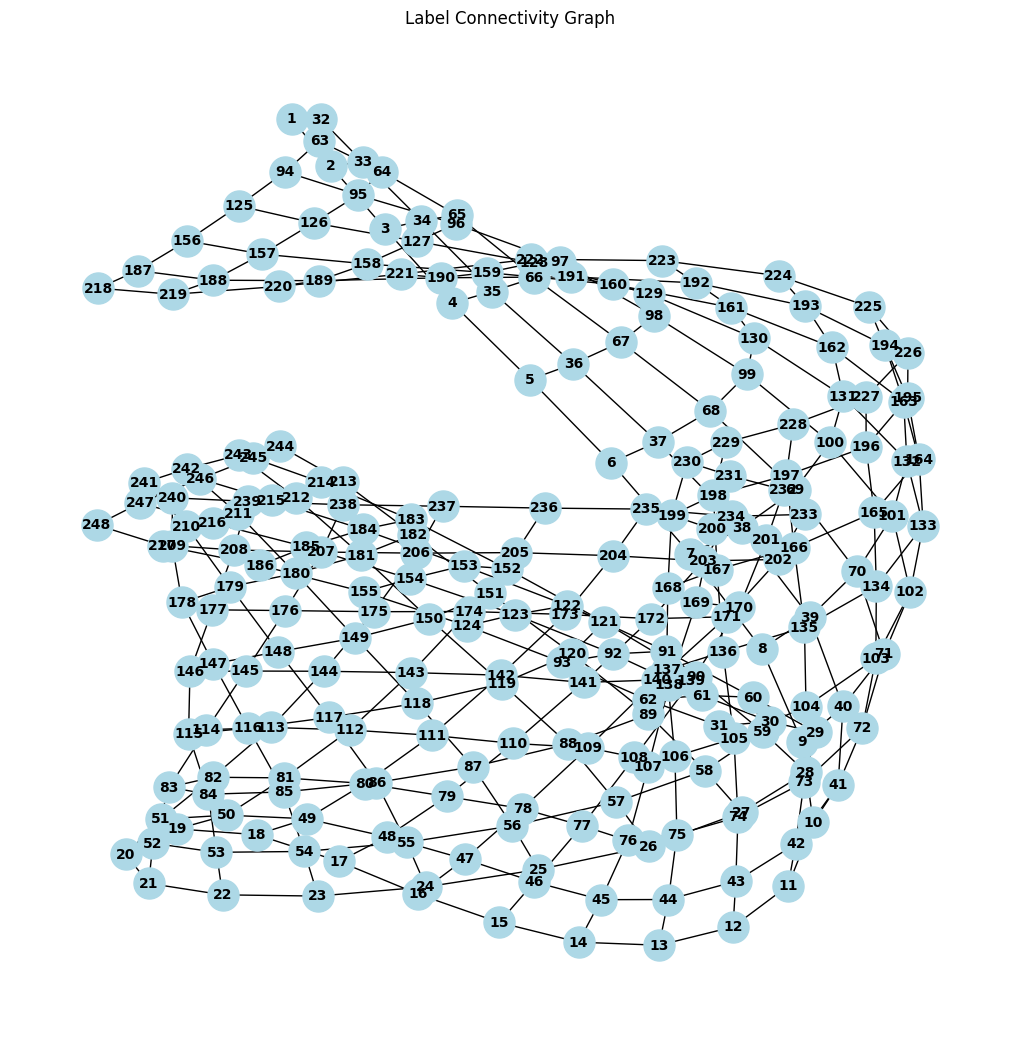

In [42]:
import numpy as np
import networkx as nx
from scipy.ndimage import binary_dilation, find_objects

import numpy as np
import networkx as nx

def construct_label_connectivity_graph(segmentation):
    """
    Construct a graph showing connectivity between unique labels,
    only connecting segments that share edges (not corners).
    
    Parameters:
    - segmentation: 2D numpy array of labeled segments
    
    Returns:
    - NetworkX graph where nodes are unique labels and edges represent valid paths
    """
    # Remove background/border labels
    unique_labels = np.unique(segmentation)
    unique_labels = unique_labels[(unique_labels != 0) & (unique_labels != 255)]
    
    # Create graph
    G = nx.Graph()
    G.add_nodes_from(unique_labels)
    
    # Get height and width of the segmentation
    height, width = segmentation.shape
    
    # Dictionary to store connections
    connections = set()
    
    # Check horizontal connections
    for i in range(height):
        for j in range(width - 1):
            label1 = segmentation[i, j]
            label2 = segmentation[i, j + 1]
            if label1 != label2 and label1 != 0 and label1 != 255 and label2 != 0 and label2 != 255:
                connections.add(tuple(sorted([label1, label2])))
    
    # Check vertical connections
    for i in range(height - 1):
        for j in range(width):
            label1 = segmentation[i, j]
            label2 = segmentation[i + 1, j]
            if label1 != label2 and label1 != 0 and label1 != 255 and label2 != 0 and label2 != 255:
                connections.add(tuple(sorted([label1, label2])))
    
    # Add edges to graph
    G.add_edges_from(connections)
    
    return G

# Optional visualization
def visualize_connectivity_graph(G):
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, 10))
    pos = nx.spring_layout(G, seed=42)
    nx.draw(G, pos, with_labels=True, node_color='lightblue', 
            node_size=500, font_size=10, font_weight='bold')
    plt.title('Label Connectivity Graph')
    plt.show()

# Example usage
G = construct_label_connectivity_graph(labeled_segmentation)
visualize_connectivity_graph(G)
print()

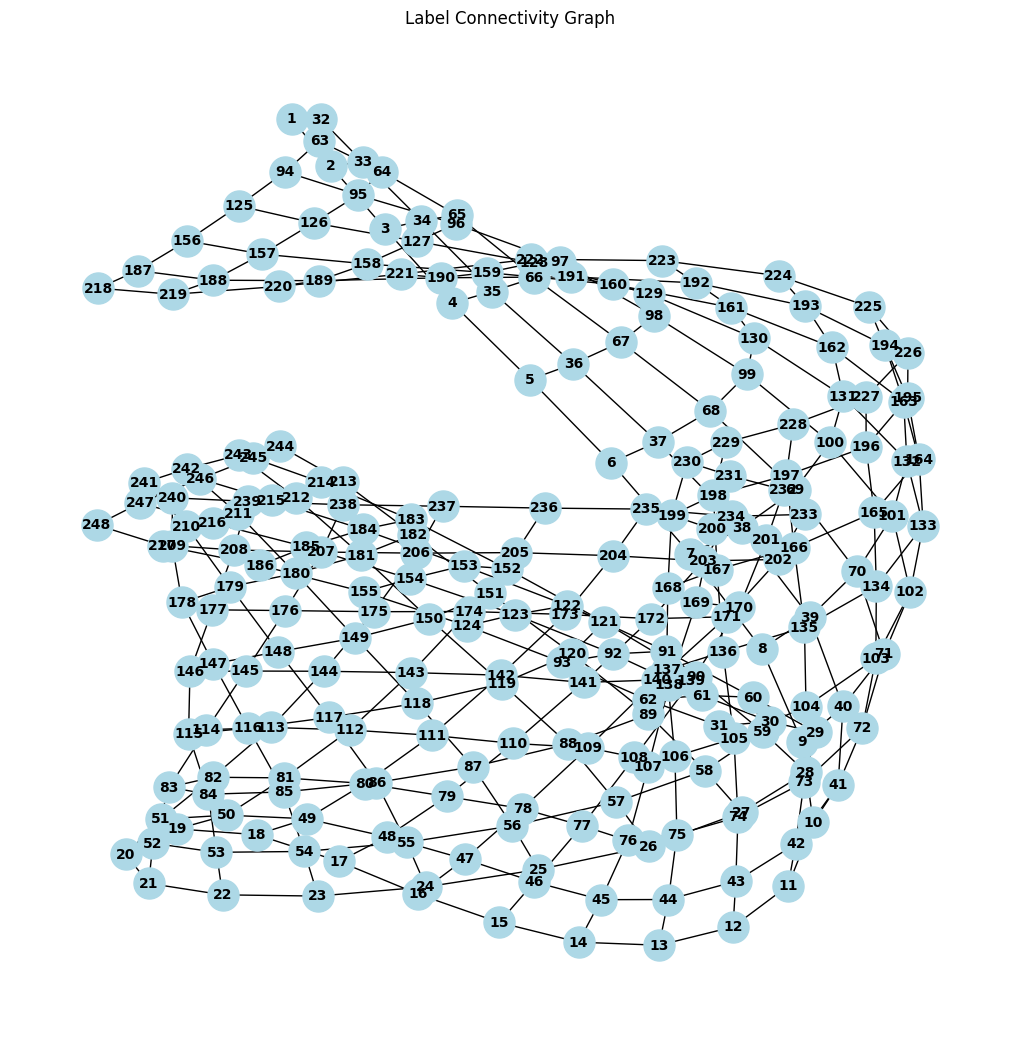

In [43]:
import numpy as np
import networkx as nx
from scipy.signal import convolve2d

def construct_label_connectivity_graph(segmentation):
    """
    Construct a graph showing connectivity between unique labels using
    separate horizontal and vertical convolutions.
    
    Parameters:
    - segmentation: 2D numpy array of labeled segments
    
    Returns:
    - NetworkX graph where nodes are unique labels
    """
    # Define horizontal and vertical kernels
    horizontal_kernel = np.array([[1, 1, 1]])  # Shape: (1, 3)
    vertical_kernel = np.array([[1], [1], [1]])  # Shape: (3, 1)
    
    # Get unique labels (excluding background/border)
    unique_labels = np.unique(segmentation)
    unique_labels = unique_labels[(unique_labels != 0) & (unique_labels != 255)]
    map_ = ~(segmentation == 0)
    
    # Create graph
    G = nx.Graph()
    G.add_nodes_from(unique_labels)
    
    # Create and store convolved masks for each label
    horizontal_masks = {}
    vertical_masks = {}
    
    for label in unique_labels:
        # Create binary mask for current label
        mask = (segmentation == label)
        
        # Convolve with horizontal and vertical kernels separately
        horizontal = convolve2d(mask.astype(int), horizontal_kernel, mode='same')
        vertical = convolve2d(mask.astype(int), vertical_kernel, mode='same')
        
        # Store the convolved masks
        horizontal_masks[label] = (horizontal > 0) & map_
        vertical_masks[label] = (vertical > 0) & map_
    
    # Check horizontal connections
    for i, label1 in enumerate(unique_labels):
        h_mask1 = segmentation == label1
        for label2 in unique_labels[i+1:]:
            h_mask2 = horizontal_masks[label2]
            intersect = h_mask1 & h_mask2
            if np.any(intersect):
                G.add_edge(label1, label2)
    
    # Check vertical connections
    for i, label1 in enumerate(unique_labels):
        v_mask1 = segmentation == label1
        for label2 in unique_labels[i+1:]:
            v_mask2 = vertical_masks[label2]
            intersect = v_mask1 & v_mask2
            if np.any(intersect):
                G.add_edge(label1, label2)
    
    return G

G = construct_label_connectivity_graph(labeled_segmentation)
visualize_connectivity_graph(G)

In [44]:
static_cost = np.nan_to_num(np.load(f'../python/static_costs/{MAP}_costs.npy'), posinf=0)
static_cost = np.clip(static_cost, 0, np.quantile(static_cost, 0.99))

In [45]:
label = 20
label_map = (labeled_segmentation == label)
label_area = label_map.sum()
avg_static_cost = (static_cost * label_map).sum() / label_area
avg_static_cost

np.float64(1.60626220703125)

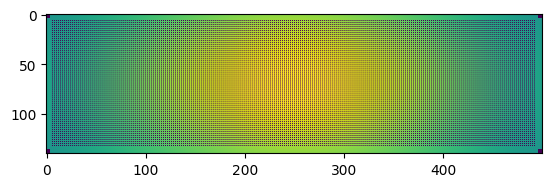

In [46]:
plt.imshow(static_cost)

In [47]:
def graph_to_connectivity_dict(G, segmentation, static_cost):
    """
    Convert graph to connectivity dict with area and static cost properties.
    
    Parameters:
    - G: NetworkX graph of label connectivity
    - segmentation: Original segmentation map
    - static_cost: Static cost map corresponding to segmentation
    
    Returns:
    - Dictionary of label connections with costs
    """
    # Compute label properties
    label_properties = {}
    for label in np.unique(segmentation):
        if label not in [0, 255]:
            # Create label mask
            label_map = (segmentation == label)
            
            # Compute label area
            label_area = label_map.sum()

            # Compute centroids
            label_coords = np.vstack(np.where(label_map))
            initial_centroid = label_coords.mean(axis=1).astype(np.uint)

            # Find nearest empty cell to serve as centroid
            empty_mask = (segmentation == label)
            if not empty_mask[initial_centroid[0], initial_centroid[1]]:
                empty_coords = np.vstack(np.where(empty_mask)).T
                distances = np.linalg.norm(empty_coords - initial_centroid, axis=1)
                nearest_empty_idx = np.argmin(distances, axis=0)
                centroid = empty_coords[nearest_empty_idx]
            else:
                centroid = initial_centroid

            
            # Compute average static cost
            avg_static_cost = (static_cost * label_map).sum() / label_area
            
            # Store properties
            label_properties[label] = {
                'area': label_area,
                'avg_static_cost': avg_static_cost,
                'centroid': centroid,
            }
    
    # Create connectivity dictionary with costs
    connectivity_dict = {}
    
    for node in G.nodes():
        # Get connected nodes
        connected_nodes = list(G.neighbors(node))
        
        # Compute connection costs
        connection_costs = {}
        for neighbor in connected_nodes:
            # Cost based on area difference and static costs
            area_diff_cost = abs(
                label_properties[node]['area'] - label_properties[neighbor]['area']
            ) / max(label_properties[node]['area'], label_properties[neighbor]['area'])
            
             # Use the neighbor's static cost directly
            neighbor_static_cost = label_properties[neighbor]['avg_static_cost']

            # Compute manhattan distance between centroids as an approximation of the distance between the two
            centroid1 = label_properties[node]['centroid']
            centroid2 = label_properties[neighbor]['centroid']
            manhattan_distance = abs(centroid1 - centroid2).sum()
            
            # Combined cost (you can adjust weights)
            combined_cost = area_diff_cost + neighbor_static_cost + manhattan_distance
            
            connection_costs[int(neighbor)] = float(combined_cost)
        
        connectivity_dict[int(node)] = {
            'connections': connection_costs,
            'centroid': label_properties[node]['centroid'].tolist()
        }
    
    return connectivity_dict

# Example usage
connectivity_dict = graph_to_connectivity_dict(G, labeled_segmentation, static_cost)

In [48]:
connectivity_dict

{1: {'connections': {2: 1.8446744073709552e+19, 32: 1.8446744073709552e+19},
  'centroid': [8, 7]},
 2: {'connections': {1: 16.066959397617357,
   3: 1.8446744073709552e+19,
   33: 1.8446744073709552e+19},
  'centroid': [7, 23]},
 3: {'connections': {2: 17.088164261409215,
   4: 1.8446744073709552e+19,
   34: 1.8446744073709552e+19},
  'centroid': [7, 39]},
 4: {'connections': {3: 17.142745903560094,
   5: 1.8446744073709552e+19,
   35: 1.8446744073709552e+19},
  'centroid': [7, 55]},
 5: {'connections': {4: 17.198439053126744,
   6: 1.8446744073709552e+19,
   36: 1.8446744073709552e+19},
  'centroid': [7, 71]},
 6: {'connections': {5: 17.25473758152553,
   7: 1.8446744073709552e+19,
   37: 1.8446744073709552e+19},
  'centroid': [7, 87]},
 7: {'connections': {6: 17.311016082763672,
   8: 1.8446744073709552e+19,
   38: 1.8446744073709552e+19},
  'centroid': [7, 103]},
 8: {'connections': {7: 17.366527557373047,
   9: 1.8446744073709552e+19,
   39: 1.8446744073709552e+19},
  'centroid': 

In [49]:
import numpy as np
import networkx as nx

def graph_to_connectivity_arrays(G, segmentation, static_cost):
    """
    Convert graph to connectivity matrix and centroids matrix optimized for Numba.
    
    Parameters:
    - G: NetworkX graph of label connectivity
    - segmentation: Original segmentation map
    - static_cost: Static cost map corresponding to segmentation
    
    Returns:
    - connectivity_matrix: 2D numpy array of connection costs
    - centroids_matrix: 2D numpy array of segment centroids
    """
    # Get unique labels, excluding 0 and 255
    labels = [label for label in np.unique(segmentation) if label not in [0, 255]]
    num_labels = max(labels) + 1
    
    # Initialize matrices
    connectivity_matrix = np.zeros((num_labels, num_labels), dtype=np.float32)
    centroids_matrix = np.zeros((num_labels, 2), dtype=np.int32)
    
    # Compute label properties
    for label in labels:
        # Create label mask
        label_map = (segmentation == label)
        
        # Compute label area
        label_area = label_map.sum()

        # Compute centroids
        label_coords = np.vstack(np.where(label_map))
        initial_centroid = label_coords.mean(axis=1).astype(int)

        # Find nearest empty cell to serve as centroid
        empty_mask = (segmentation == label)
        if not empty_mask[initial_centroid[0], initial_centroid[1]]:
            empty_coords = np.vstack(np.where(empty_mask)).T
            distances = np.linalg.norm(empty_coords - initial_centroid, axis=1)
            nearest_empty_idx = np.argmin(distances, axis=0)
            centroid = empty_coords[nearest_empty_idx]
        else:
            centroid = initial_centroid

        # Compute average static cost
        avg_static_cost = (static_cost * label_map).sum() / label_area
        
        # Store centroid
        centroids_matrix[label] = centroid
        
        # Compute connection costs
        for neighbor in G.neighbors(label):
            # Skip if neighbor is not a valid label
            if neighbor not in labels:
                continue
            
            # Compute label mask for neighbor
            neighbor_map = (segmentation == neighbor)
            neighbor_area = neighbor_map.sum()
            neighbor_static_cost = (static_cost * neighbor_map).sum() / neighbor_area
            
            # Cost based on area difference and static costs
            area_diff_cost = abs(label_area - neighbor_area) / max(label_area, neighbor_area)
            
            # Compute manhattan distance between centroids
            manhattan_distance = abs(centroid - centroids_matrix[neighbor]).sum()
            
            # Combined cost
            combined_cost = area_diff_cost + neighbor_static_cost + manhattan_distance
            
            # Store in connectivity matrix
            connectivity_matrix[label, neighbor] = float(combined_cost)
    
    return connectivity_matrix, centroids_matrix

connectivity_matrix, centroids_matrix = graph_to_connectivity_arrays(G, labeled_segmentation, static_cost)

In [50]:
connectivity_matrix

array([[  0.      ,   0.      ,   0.      , ...,   0.      ,   0.      ,
          0.      ],
       [  0.      ,   0.      ,  16.118467, ...,   0.      ,   0.      ,
          0.      ],
       [  0.      ,  18.06696 ,   0.      , ...,   0.      ,   0.      ,
          0.      ],
       ...,
       [  0.      ,   0.      ,   0.      , ...,   0.      , 586.1068  ,
          0.      ],
       [  0.      ,   0.      ,   0.      , ...,  17.162443,   0.      ,
        602.24347 ],
       [  0.      ,   0.      ,   0.      , ...,   0.      ,  18.302227,
          0.      ]], dtype=float32)

In [51]:
connectivity_matrix.shape

(249, 249)

In [52]:
centroids_matrix

array([[  0,   0],
       [  8,   7],
       [  7,  23],
       [  7,  39],
       [  7,  55],
       [  7,  71],
       [  7,  87],
       [  7, 103],
       [  7, 119],
       [  7, 135],
       [  7, 151],
       [  7, 167],
       [  7, 183],
       [  7, 199],
       [  7, 215],
       [  7, 231],
       [  7, 247],
       [  7, 263],
       [  7, 279],
       [  7, 295],
       [  7, 311],
       [  7, 327],
       [  7, 343],
       [  7, 359],
       [  7, 375],
       [  7, 391],
       [  7, 407],
       [  7, 423],
       [  7, 439],
       [  7, 455],
       [  7, 471],
       [  7, 489],
       [ 25,   7],
       [ 25,  24],
       [ 25,  40],
       [ 25,  56],
       [ 25,  72],
       [ 25,  88],
       [ 25, 104],
       [ 25, 120],
       [ 25, 136],
       [ 25, 152],
       [ 25, 168],
       [ 25, 184],
       [ 25, 200],
       [ 25, 216],
       [ 25, 232],
       [ 25, 248],
       [ 25, 264],
       [ 25, 280],
       [ 25, 296],
       [ 25, 312],
       [ 25,

In [53]:
np.save(f'../python/high_level_graph/{MAP}_segmentation.npy', labeled_segmentation)
np.save(f'../python/high_level_graph/{MAP}_connectivity.npy', connectivity_matrix)
np.save(f'../python/high_level_graph/{MAP}_centroids.npy', centroids_matrix)

In [54]:
curr_room = 7
neighbors = np.where(connectivity_matrix[curr_room] > 0)[0]
for next_room in neighbors:
    transition_cost = connectivity_matrix[curr_room][next_room]
    print(transition_cost)

17.311016
111.42041
111.487144
